# Electricity price floor & asymmetry techniques comparison

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

current_dir = Path.cwd()
project_root = None
if (current_dir / 'config.py').exists():
    project_root = str(current_dir)
elif (current_dir.parent / 'config.py').exists():
    project_root = str(current_dir.parent)

if project_root and project_root not in sys.path:
    sys.path.insert(0, project_root)

from models import (
    ProbabilisticTransformer,
    HybridProbabilisticTransformer,
    HybridProbabilisticTransformerOUJump,
    HybridProbabilisticTransformerHourlyOU,
    HybridProbabilisticTransformerSoftBarrierOU,
    HybridProbabilisticTransformerAsymmetricJump,
)
from core.experiment_utils import (
    load_data, load_cache, save_cache, run_experiment, N_RUNS,
)

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

try:
    gpus = tf.config.experimental.list_physical_devices("GPU")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs detected: {len(gpus)}")
except Exception as e:
    print(f"GPU config failed: {e}")

2026-03-09 11:23:58.930555: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773051838.946926 2790293 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773051838.951827 2790293 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773051838.964639 2790293 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773051838.964655 2790293 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773051838.964657 2790293 computation_placer.cc:177] computation placer alr

GPUs detected: 1


In [2]:
RESULTS_DIR = Path(project_root) / "results" / "price_floor_comparison"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = RESULTS_DIR / "results.json"

In [3]:
# All metrics and caching handled by core.experiment_utils

In [4]:
data = load_data()

Data loaded  —  Train: 10366, Val: 1997, Test: 3722


In [5]:
# Model configurations: (display_name, model_class, head_type, head_params, is_hybrid, apply_posthoc_floor)
# Added: Soft Barrier OU (soft floor near zero), Asymmetric Jump (larger upward spikes).
MODEL_CONFIGS = [
    ("Baseline (Gaussian)", ProbabilisticTransformer, "gaussian", {}, False, False),
    ("Baseline (Johnson SU)", ProbabilisticTransformer, "johnson_su", {}, False, False),
    ("Johnson SU + Floor", ProbabilisticTransformer, "johnson_su_floor", {"floor_penalty_weight": 0.1, "asymmetric_weight": 1.5}, False, False),
    ("Hybrid (Transformer+OU)", HybridProbabilisticTransformer, "johnson_su", {}, True, False),
    ("Hybrid + OU + Jump", HybridProbabilisticTransformerOUJump, "johnson_su", {}, True, False),
    ("Hybrid + Hourly OU", HybridProbabilisticTransformerHourlyOU, "johnson_su", {"hour_col_idx": 1}, True, False),
    ("Hybrid + Soft Barrier OU", HybridProbabilisticTransformerSoftBarrierOU, "johnson_su", {}, True, False),
    ("Hybrid + Asymmetric Jump", HybridProbabilisticTransformerAsymmetricJump, "johnson_su", {}, True, False),
]

In [6]:
cache = load_cache(CACHE_FILE)

for model_name, model_cls, head_type, head_params, is_hybrid, apply_posthoc_floor in MODEL_CONFIGS:
    run_experiment(
        model_cls, model_name, data,
        str(RESULTS_DIR),
        cache=cache,
        is_hybrid=is_hybrid,
        head_type=head_type,
        head_params=head_params,
    )

save_cache(CACHE_FILE, cache)
print("\nAll experiments complete.")

[Baseline (Gaussian)] found in cache — skipping.
[Baseline (Johnson SU)] found in cache — skipping.
[Johnson SU + Floor] found in cache — skipping.
[Hybrid (Transformer+OU)] found in cache — skipping.
[Hybrid + OU + Jump] found in cache — skipping.
[Hybrid + Hourly OU] found in cache — skipping.
[Hybrid + Soft Barrier OU] found in cache — skipping.
[Hybrid + Asymmetric Jump] found in cache — skipping.

All experiments complete.


In [7]:
# Results summary
results = []
for model_name, metrics in cache.items():
    results.append({"Model": model_name, **metrics})

df_res = pd.DataFrame(results)
if not df_res.empty:
    df_sorted = df_res.sort_values("MAE")
    display(df_sorted)
    df_sorted.to_csv(RESULTS_DIR / "comparison_summary.csv", index=False)
    print(f"\nResults saved to {RESULTS_DIR / 'comparison_summary.csv'}")

,Model,MAE,MSE,RMSE,MAPE,R2,PICP,MPIW,PINAW,IntervalScore,CRPS,NLL,Pinball_10,Pinball_50,Pinball_90,Avg_Pinball,training_time
4,Hybrid + OU + Jump,20.034581,721.284108,26.836217,1980.198467,0.487305,0.922223,102.176854,0.283661,148.029446,14.485555,NaN,4.873259,9.943156,4.737318,6.517911,104.913863
1,Baseline (Johnson SU),20.057467,719.495423,26.812056,1913.702071,0.488576,0.882106,87.438884,0.242746,151.870869,14.513224,57.964658,4.935197,9.806083,4.770993,6.504091,105.558888
2,Johnson SU + Floor,20.177610,740.582575,27.033082,2276.621002,0.473587,0.920163,102.769101,0.285305,148.403813,14.605409,49.325516,4.966955,9.906117,4.662738,6.511937,100.693764
5,Hybrid + Hourly OU,20.412569,741.886965,27.225394,1992.209316,0.472660,0.941411,107.277820,0.297822,142.495225,14.723325,NaN,4.847781,10.145927,4.813020,6.602242,108.969516
3,Hybrid (Transformer+OU),20.480947,745.155259,27.279524,1914.645754,0.470337,0.898647,92.337480,0.256345,150.684684,14.710128,NaN,4.885251,10.103604,4.856104,6.614986,109.936386
6,Hybrid + Soft Barrier OU,20.516949,757.402080,27.512354,1945.851439,0.461632,0.915352,98.517814,0.273503,149.700998,14.748473,NaN,4.926347,10.140916,4.826319,6.631194,107.484226
0,Baseline (Gaussian),21.424496,802.244170,28.298938,1895.033531,0.429758,0.912281,95.315466,0.264613,147.055447,15.543165,20850.744799,4.912823,10.712248,5.024177,6.883083,104.369423
7,Hybrid + Asymmetric Jump,21.714511,805.463510,28.369284,2049.665560,0.427470,0.993647,251.351000,0.697795,254.691706,19.830571,NaN,5.519310,12.369972,9.862377,9.250553,106.384319



Results saved to /home/d1ff1cult/masterproef_new/results/price_floor_comparison/comparison_summary.csv


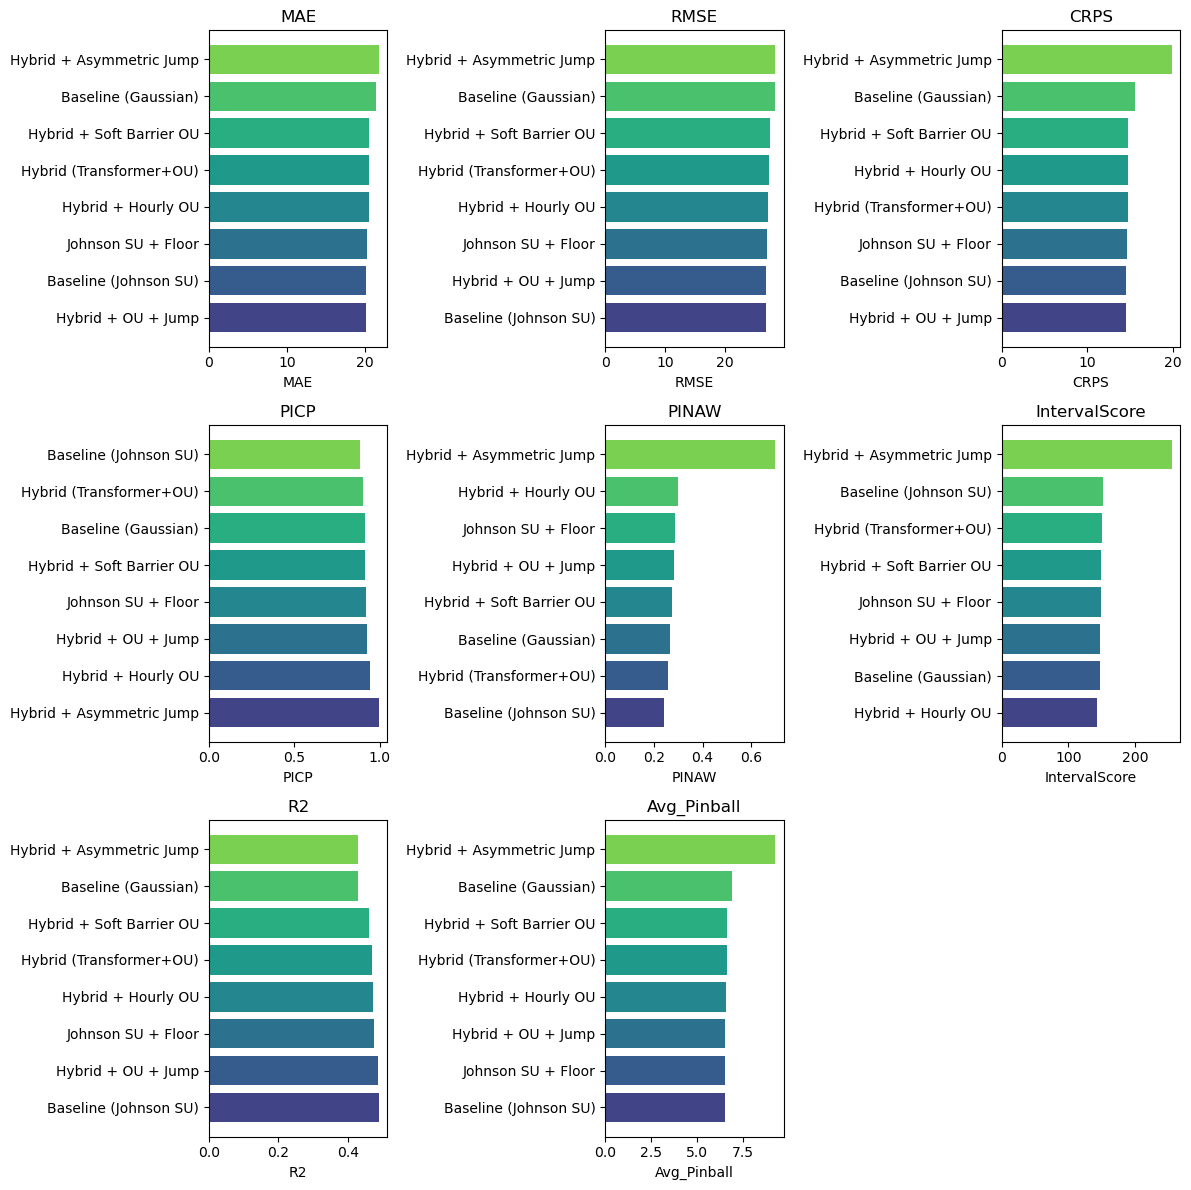

Plot saved to /home/d1ff1cult/masterproef_new/results/price_floor_comparison/comparison_charts.png


In [8]:
# Bar charts for key metrics
if not df_res.empty:
    import matplotlib.pyplot as plt

    metrics_to_plot = ["MAE", "RMSE", "CRPS", "PICP", "PINAW", "IntervalScore", "R2", "Avg_Pinball"]
    metrics_avail = [m for m in metrics_to_plot if m in df_res.columns]
    n_plots = len(metrics_avail)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    if n_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for ax, metric in zip(axes[:n_plots], metrics_avail):
        ascending = metric not in ("R2", "PICP")
        df_plot = df_res.sort_values(metric, ascending=ascending)
        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(df_plot)))
        ax.barh(df_plot["Model"], df_plot[metric], color=colors)
        ax.set_xlabel(metric)
        ax.set_title(metric)

    for ax in axes[n_plots:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "comparison_charts.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved to {RESULTS_DIR / 'comparison_charts.png'}")